In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np

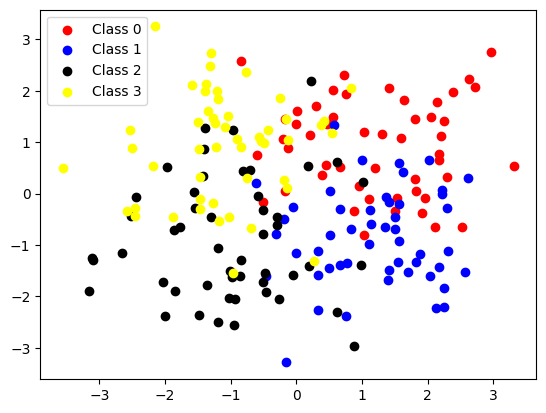

In [7]:
# Generate 50 points for each group
x = []
x.append(np.random.randn(50, 2) + np.array([1, 1]))
x.append(np.random.randn(50, 2) + np.array([1, -1]))
x.append(np.random.randn(50, 2) + np.array([-1, -1]))
x.append(np.random.randn(50, 2) + np.array([-1, 1]))
x = np.concatenate(x, axis=0)
y = np.zeros(x.shape[0])
y[50:100] += 1
y[100:150] += 2
y[150:200] += 3

indx = np.arange(x.shape[0])
np.random.shuffle(indx)

x = x[indx,:]
y = y[indx]

# Plotting the samples
plt.scatter(x[y==0,0], x[y==0,1], color='red', label='Class 0')
plt.scatter(x[y==1,0], x[y==1,1], color='blue', label='Class 1')
plt.scatter(x[y==2,0], x[y==2,1], color='black', label='Class 2')
plt.scatter(x[y==3,0], x[y==3,1], color='yellow', label='Class 3')

# Set plot labels and title
plt.legend()
# plt.grid(True)
plt.show()

In [8]:
x[y == 0].shape

(50, 2)

Accuracy: 52.50%


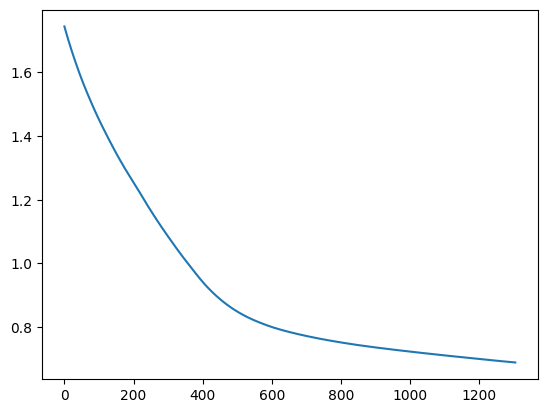

In [15]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

model = MLPClassifier(max_iter=10000 , hidden_layer_sizes=5) #

indx_train = np.arange(x.shape[0]*20//100)
x_train, y_train = x[indx_train,:], y[indx_train]
x_test, y_test = x[~indx_train,:], y[~indx_train]

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy*100:.2f}%')

plt.plot(model.loss_curve_)

In [16]:
print(len(model.coefs_), model.coefs_[0].shape, model.coefs_[1].shape)

2 (2, 5) (5, 4)


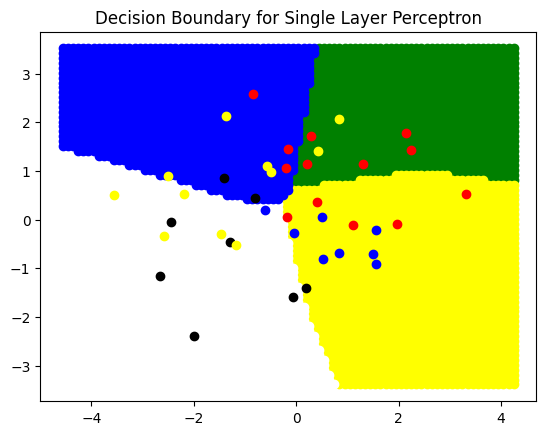

In [17]:
# Create a mesh grid over the feature space
x_min, x_max = x_test[:, 0].min() - 1, x_test[:, 0].max() + 1
y_min, y_max = x_test[:, 1].min() - 1, x_test[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict the class for each point in the mesh grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
# Z = Z.reshape(xx.shape)

# Plot the decision boundaries
# plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(xx.ravel()[Z==0], yy.ravel()[Z==0], color='green')
plt.scatter(xx.ravel()[Z==1], yy.ravel()[Z==1], color='yellow')
plt.scatter(xx.ravel()[Z==2], yy.ravel()[Z==2], color='white')
plt.scatter(xx.ravel()[Z==3], yy.ravel()[Z==3], color='blue')

# Plotting the samples
plt.scatter(x_test[y_test==0,0], x_test[y_test==0,1], color='red', label='Class 0')
plt.scatter(x_test[y_test==1,0], x_test[y_test==1,1], color='blue', label='Class 1')
plt.scatter(x_test[y_test==2,0], x_test[y_test==2,1], color='black', label='Class 2')
plt.scatter(x_test[y_test==3,0], x_test[y_test==3,1], color='yellow', label='Class 3')

plt.title('Decision Boundary for Single Layer Perceptron')
# plt.legend()
# plt.grid(True)
plt.show()

In [57]:
yy.ravel().shape

(15678,)